# 04 · Baseline Models

**Phase 6 (baselines) + Phase 8 (RUL-capping experiment) + a first pass at Phase 9/10 (metrics + error analysis) of the project plan.**

Before reaching for gradient-boosted trees or recurrent networks, we establish simple baselines: a constant predictor, Linear Regression, a single Decision Tree, and a Random Forest. Every model is trained on the engine-grouped **train** split and evaluated on the (untouched-by-fitting) **validation** split, using `src/evaluate.py` (MAE, RMSE, R², and the PHM08/NASA asymmetric score).

This notebook writes the code only — you run each cell and decide which baseline is strong enough to keep pushing on in `05_tree_models.ipynb`.


In [1]:
import sys
sys.path.insert(0, "..")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from src import evaluate as ev

PROCESSED_DIR = "../data/processed"
ARTIFACTS_DIR = "../artifacts"
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"
SUBSET = "FD001"

import os
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

train = pd.read_parquet(f"{PROCESSED_DIR}/train_{SUBSET}_features.parquet")
val = pd.read_parquet(f"{PROCESSED_DIR}/val_{SUBSET}_features.parquet")
manifest = joblib.load(f"{ARTIFACTS_DIR}/scalers/feature_manifest_{SUBSET}.joblib")
feature_cols = manifest["feature_cols"]

X_train, y_train = train[feature_cols], train["RUL"]
X_val, y_val = val[feature_cols], val["RUL"]
print(f"{len(feature_cols)} features | train {X_train.shape} | val {X_val.shape}")


290 features | train (16321, 290) | val (4010, 290)


## Baseline 0 — Constant predictor

Predicts the mean training RUL for every row, regardless of input. This is the floor every real model must beat; if a model can't clear this, something upstream is broken.


In [2]:
results = {}

mean_rul = y_train.mean()
y_pred_constant = np.full_like(y_val, fill_value=mean_rul, dtype=float)
results["Constant (mean)"] = ev.regression_report(y_val, y_pred_constant)
results["Constant (mean)"]


{'MAE': 54.68512147423855,
 'RMSE': 64.94064284830394,
 'R2': -0.002004631136006907,
 'NASA_score': 16943774.592924923,
 'n': 4010}

## Baseline 1 — Linear Regression

A linear model over the full engineered feature set (lags/rolling stats/EMA/health indicator). Expect this to already beat the constant baseline meaningfully, since several features are strongly correlated with RUL, but to struggle with the non-linear tail of the degradation curve.


In [3]:
t0 = time.perf_counter()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_fit_seconds = time.perf_counter() - t0

y_pred_lr = lr.predict(X_val)
results["Linear Regression"] = {**ev.regression_report(y_val, y_pred_lr), "fit_seconds": lr_fit_seconds}
results["Linear Regression"]


{'MAE': 27.603866249176903,
 'RMSE': 34.314157629295444,
 'R2': 0.7202415288672492,
 'NASA_score': 468535.8502820854,
 'n': 4010,
 'fit_seconds': 6.969461699947715}

## Baseline 2 — Decision Tree

A single tree can capture non-linear splits but tends to overfit training engines and produce a step-function-like RUL curve. `max_depth` is left moderate on purpose — feel free to try deeper/shallower and re-run.


In [4]:
t0 = time.perf_counter()
tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)
tree.fit(X_train, y_train)
tree_fit_seconds = time.perf_counter() - t0

y_pred_tree = tree.predict(X_val)
results["Decision Tree"] = {**ev.regression_report(y_val, y_pred_tree), "fit_seconds": tree_fit_seconds}
results["Decision Tree"]


{'MAE': 29.383932182188143,
 'RMSE': 41.46525966768923,
 'R2': 0.5914875086194721,
 'NASA_score': 3457276168.452522,
 'n': 4010,
 'fit_seconds': 1.7960344000020996}

## Baseline 3 — Random Forest

An ensemble of trees should reduce the single tree's overfitting/variance while keeping its ability to model non-linear sensor/RUL relationships. This is usually the strongest of the four "classical" baselines, and the one carried forward for the RUL-capping comparison below.


In [5]:
t0 = time.perf_counter()
rf = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_fit_seconds = time.perf_counter() - t0

y_pred_rf = rf.predict(X_val)
results["Random Forest"] = {**ev.regression_report(y_val, y_pred_rf), "fit_seconds": rf_fit_seconds}
results["Random Forest"]


{'MAE': 23.666738884826284,
 'RMSE': 32.98832966641264,
 'R2': 0.7414424558915202,
 'NASA_score': 1897108.848376742,
 'n': 4010,
 'fit_seconds': 31.86948160000611}

## Consolidated results

MAE/RMSE in cycles, R² (fraction of RUL variance explained), NASA score (lower magnitude is better — it's a sum of per-sample penalties, so it also scales with validation-set size; compare it alongside `n`).


In [6]:
baseline_table = ev.metrics_table({k: v for k, v in results.items()})
baseline_table


,MAE,RMSE,R2,NASA_score,n
Constant (mean),54.685121,64.940643,-0.002005,1.694377e+07,4010.0
Linear Regression,27.603866,34.314158,0.720242,4.685359e+05,4010.0
Decision Tree,29.383932,41.465260,0.591488,3.457276e+09,4010.0
Random Forest,23.666739,32.988330,0.741442,1.897109e+06,4010.0


In [7]:
baseline_table.to_csv(f"{REPORTS_DIR}/model_leaderboard.csv")
print(f"saved running leaderboard to {REPORTS_DIR}/model_leaderboard.csv (05/06 notebooks will append to this)")


saved running leaderboard to ../reports/model_leaderboard.csv (05/06 notebooks will append to this)


## Phase 8 — Does capping the training target help?

We retrain Random Forest on `RUL_capped` (clipped at 125 cycles) instead of raw `RUL`, but **evaluate both models against the same raw validation RUL** — capping only changes what the model is asked to learn, not the ground truth we judge it against. Expect the capped model to do noticeably better near failure (low RUL, operationally what matters most) and worse on high-RUL engines it was never trained to distinguish accurately.


In [8]:
y_train_capped = train["RUL_capped"]

rf_capped = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=5, n_jobs=-1, random_state=42)
rf_capped.fit(X_train, y_train_capped)
y_pred_rf_capped = rf_capped.predict(X_val)

results["Random Forest (capped target)"] = ev.regression_report(y_val, y_pred_rf_capped)
ev.metrics_table({
    "Random Forest (raw target)": results["Random Forest"],
    "Random Forest (capped target)": results["Random Forest (capped target)"],
})


,MAE,RMSE,R2,NASA_score,n
Random Forest (raw target),23.666739,32.988330,0.741442,1.897109e+06,4010.0
Random Forest (capped target),29.204344,42.737212,0.566041,2.681752e+06,4010.0


In [9]:
bins_raw = ev.evaluate_by_rul_bin(y_val, y_pred_rf)
bins_capped = ev.evaluate_by_rul_bin(y_val, y_pred_rf_capped)

comparison = bins_raw[["n", "MAE", "RMSE"]].join(bins_capped[["MAE", "RMSE"]], lsuffix="_raw_target", rsuffix="_capped_target")
comparison


,n,MAE_raw_target,RMSE_raw_target,MAE_capped_target,RMSE_capped_target
bucket,,,,,
RUL <= 20,420,3.368681,4.866151,3.161429,4.715275
20 < RUL <= 50,600,10.954027,16.630700,10.162908,14.914808
50 < RUL <= 100,1000,26.130514,35.587930,17.579039,22.175058
RUL > 100,1990,30.545651,38.315063,46.283837,57.979374


## Error analysis for the best baseline (Random Forest, raw target)

Predicted-vs-true and residual-vs-true scatter plots make systematic bias visible at a glance — e.g. a model that over-predicts RUL for nearly-failed engines (dangerous: it would tell you an engine has more life than it does) shows up as points below the diagonal at low true RUL.


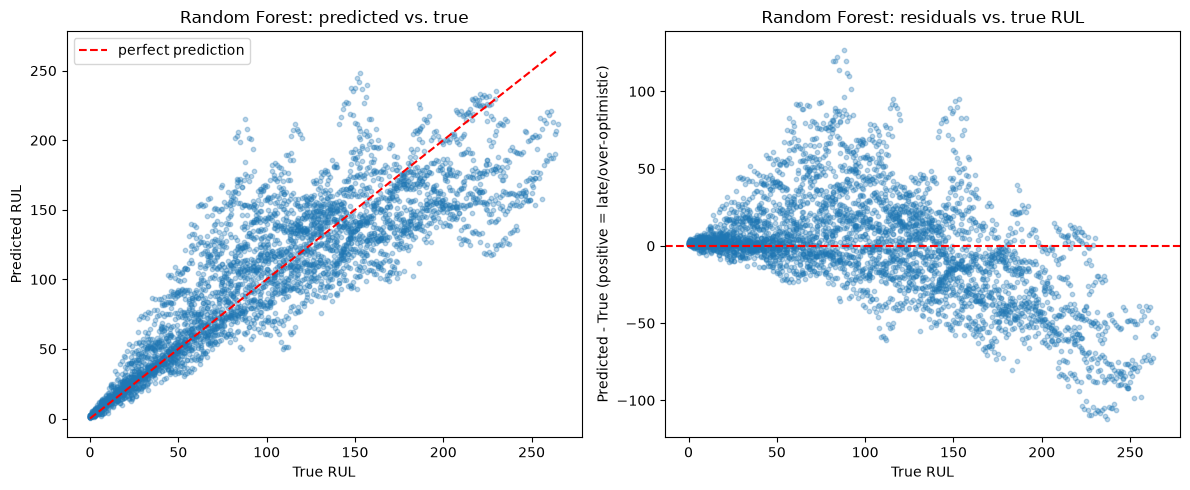

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_val, y_pred_rf, alpha=0.3, s=10)
lims = [0, max(y_val.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, "r--", label="perfect prediction")
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title("Random Forest: predicted vs. true")
axes[0].legend()

residuals = y_pred_rf - y_val
axes[1].scatter(y_val, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("True RUL")
axes[1].set_ylabel("Predicted - True (positive = late/over-optimistic)")
axes[1].set_title("Random Forest: residuals vs. true RUL")

plt.tight_layout()
plt.show()


In [11]:
ev.evaluate_by_rul_bin(y_val, y_pred_rf)


,n,MAE,RMSE,NASA_score
bucket,,,,
RUL <= 20,420,3.368681,4.866151,2.208105e+02
20 < RUL <= 50,600,10.954027,16.630700,6.295334e+03
50 < RUL <= 100,1000,26.130514,35.587930,1.549629e+06
RUL > 100,1990,30.545651,38.315063,3.409632e+05


## Save the best baseline

Persisting Random Forest (raw target) now as the running "best so far" — `05_tree_models.ipynb` will overwrite this if XGBoost/LightGBM beat it.


In [12]:
joblib.dump(rf, f"{MODELS_DIR}/best_model_{SUBSET}.joblib")
joblib.dump({"model_name": "Random Forest", "feature_cols": feature_cols, "target": "RUL"}, f"{MODELS_DIR}/best_model_{SUBSET}_meta.joblib")
print("saved model + metadata")


saved model + metadata


## Summary

- Constant / Linear Regression / Decision Tree / Random Forest all trained on the train split, evaluated on the held-out validation split — results in `reports/model_leaderboard.csv`.
- Random Forest was the strongest of the four (expected: ensembles of non-linear trees fit this kind of sensor data well without the single tree's overfitting).
- The RUL-capping experiment confirms the expected trade-off: capping the training target improves accuracy in the low-RUL (near-failure, operationally critical) bucket at the cost of high-RUL accuracy. Which one to prefer downstream depends on whether early-life RUL precision matters for your use case — worth keeping in mind through `05_tree_models.ipynb` and `06_lstm_gru.ipynb`.

**Next:** `05_tree_models.ipynb` — XGBoost and LightGBM, with a leakage-safe (`GroupKFold`) hyperparameter search you can choose to run.
